In [25]:
import pandas
from dataset import BraindumpDataset, split_dataset
from tokenizer import Tokenizer
import torch
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
df = pandas.read_csv("dataset_5000.csv")
df.head(10)

,input_text,target_text
0,Schedule a meeting with Sarah by Friday and re...,1. Schedule meeting with Sarah by Friday | 2. ...
1,"Don't let me forget to buy protein powder, it'...",1. Buy protein powder | 2. water the plants
2,"Don't let me forget to buy a new keyboard, it'...",1. Buy a new keyboard | 2. pick up dry cleaning
3,"Gotta run the database backup, pick up dry cle...",1. run the database backup | 2. pick up dry cl...
4,Schedule a meeting with the client at midnight...,1. Schedule meeting with the client at midnigh...
5,Remind me to clean the bathroom and I also hav...,1. clean the bathroom | 2. deploy the containe...
6,Remind me to wash the car and I also have to f...,1. wash the car | 2. fix the UI bug by Friday
7,Schedule a meeting with Alex by Friday and rem...,1. Schedule meeting with Alex by Friday | 2. f...
8,"Don't let me forget to buy HDMI cable, it's ur...",1. Buy HDMI cable | 2. take out the trash
9,"I need to buy a new keyboard this weekend, oh ...",1. Buy a new keyboard | 2. Tell mom to finish ...


In [27]:
all_text = " ".join(df['input_text'].astype(str).tolist() + df['target_text'].astype(str).tolist())
tokenizer = Tokenizer(all_text)

In [28]:
for input_text, target_text in zip(df['input_text'], df['target_text']):
    input_ids = tokenizer.encode(input_text)
    target_ids = tokenizer.encode(target_text)
    inputs_words = tokenizer.decode(input_ids)
    print(f"Input IDs: {input_ids}")
    print(f"Target IDs: {target_ids}")
    print(f"Input words: {inputs_words}")
    break
    

Input IDs: [78, 8, 54, 100, 77, 21, 42, 11, 70, 88, 75, 84, 29, 14, 3]
Target IDs: [4, 3, 78, 54, 100, 77, 21, 42, 101, 5, 3, 75, 84, 29, 14]
Input words: schedule a meeting with sarah by friday and remember to run the database backup .


In [29]:
def encode_row(text):
    return tokenizer.encode(text)

df['input_ids'] = df['input_text'].apply(encode_row)
df['target_ids'] = df['target_text'].apply(encode_row)
dataset = BraindumpDataset(df)


In [30]:
tokenizer.decode(df['input_ids'][2]), df['input_text'][2]

("don ' t let me forget to buy a new keyboard , it ' s urgent ! and pick up dry cleaning .",
 "Don't let me forget to buy a new keyboard, it's urgent! And pick up dry cleaning.")

In [31]:
tokenizer.decode(df['target_ids'][2]), df['target_text'][2]

('1 . buy a new keyboard | 2 . pick up dry cleaning',
 '1. Buy a new keyboard | 2. pick up dry cleaning')

In [32]:
#Need to Add Padding becuase there is a difference in Sequence Lenght input vs label
print(len(dataset[1][0]), len(dataset[1][1]))

21 11


In [34]:
train_dataset, val_dataset, test_dataset = split_dataset(dataset, 32)

In [35]:
trainer_loader = iter(train_dataset)
batch_trainer = next(trainer_loader)
[len(i) for i in batch_trainer['tokenized_input']][0], [len(i) for i in batch_trainer['label']][0]

(23, 20)

In [36]:
validation_loader = iter(val_dataset)
batch2 = next(validation_loader)
[len(i) for i in batch2['tokenized_input']][0], [len(i) for i in batch2['label']][0]

(22, 19)

In [37]:
test_loader = iter(test_dataset)
batch_test = next(test_loader)
[len(i) for i in batch_test['tokenized_input']][0], [len(i) for i in batch_test['label']][0]

(23, 20)

## Training the Model Seq2Seq

In [61]:
from models import Encoder, Decoder, Seq2Seq
import torch.nn as nn
import torch.optim as optim
from utils import init_weights, plot_weights_initialization, count_parameters_model
import tqdm as notebook_tqdm
import tqdm
import numpy as np

In [62]:
input_dim = tokenizer.get_vocab_size()
output_dim = tokenizer.get_vocab_size()
assert input_dim == output_dim, "Encoder and Decoder must have the same vocabulary size because they share the same tokenizer"

encoder_hidden_dim = 128
decoder_hidden_dim = 128

hidden_dim = 312
n_layers = 2

encoder_dropout = 0.4
decoder_dropout = 0.4
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

encoder = Encoder(
    input_dim=input_dim,
    embedding_dim=encoder_hidden_dim,
    hidden_dim=hidden_dim,
    n_layers=n_layers,
    dropout=encoder_dropout
)

decoder = Decoder(
    output_dim=output_dim,
    embedding_dim=decoder_hidden_dim,
    hidden_dim=hidden_dim,
    n_layers=n_layers,
    dropout=decoder_dropout
)

Seq2Seq_model = Seq2Seq(
    encoder=encoder,
    decoder=decoder,
    device=device
)

### Weight initialization

In the paper the state the initialization of the weights from a uniform distribution of -0.08 and 0.08


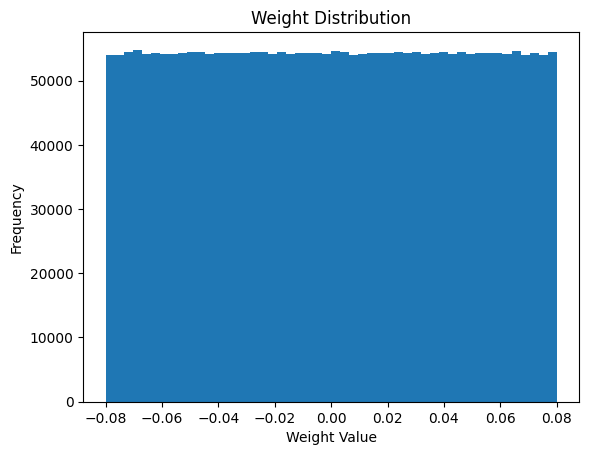

In [63]:
Seq2Seq_model.apply(init_weights)

plot_weights_initialization(Seq2Seq_model) #Plot initialization for seeing the distribution of the weihgts
    

In [64]:
sum_parameters = count_parameters_model(Seq2Seq_model)
print(f"The total parameters of the model {sum_parameters}")

The total parameters of the model 2724904


#### Optimizer

In [65]:
optimizer = optim.Adam(Seq2Seq_model.parameters())

#### Loss Function

The CrossEntropyLoss function calculates both the log softmax as well as the negative log-likelihood of our predictions.

In [66]:
pad_idx = 0 #Its zero because in the custom_collate, I'm adding 0's for the padding of the sequences
criterion = nn.CrossEntropyLoss(ignore_index = pad_idx)

#### Training Loop

At each iteration:

1. Get the source and target sentences from the batch, and zero the gradients calculated from the last batch.
2. Feed the source and target into the model to get the output.
3. As the loss function only works on 2D inputs with 1D targets, we need to flatten each of them with `.view`.
4. We slice off the first column of the output and target tensors as mentioned above.
5. Calculate the gradients with `loss.backward()`.
6. Clip the gradients to prevent them from exploding (a common issue in RNNs).
7. Update the parameters of our model by doing an optimizer step.
8. Sum the loss value to a running total.

In [67]:
from utils import train_fuction, validation_fuction
import matplotlib.pyplot as plt


In [68]:
n_epochs = 10
clip = 1.0
teacher_forcing_ratio = 0.5
best_valid_loss = float('inf')
train_losses = []
validation_losses = []

for epoch in tqdm.tqdm(range(n_epochs)):
    train_loss = train_fuction(
        Seq2Seq_model,
        train_dataset,
        optimizer,
        criterion,
        clip,
        teacher_forcing_ratio,
        device)
    validation_loss = validation_fuction(
        Seq2Seq_model,
        val_dataset,
        criterion,
        device
    )
    
    train_losses.append(train_loss)
    validation_losses.append(validation_loss)
    
    if validation_loss < best_valid_loss:
        best_valid_loss = validation_loss
        torch.save(Seq2Seq_model.state_dict(), "tut1-model.pt")
    
    print(f"\tTrain Loss: {train_loss:7.3f} | Train PPL: {np.exp(train_loss):7.3f}")
    print(f"\tValid Loss: {validation_loss:7.3f} | Valid PPL: {np.exp(validation_loss):7.3f}")

  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:31<04:47, 31.96s/it]

	Train Loss:   2.875 | Train PPL:  17.730
	Valid Loss:   2.154 | Valid PPL:   8.618


 20%|██        | 2/10 [01:01<04:03, 30.47s/it]

	Train Loss:   1.894 | Train PPL:   6.645
	Valid Loss:   1.606 | Valid PPL:   4.985


...

	Train Loss:   1.029 | Train PPL:   2.798
	Valid Loss:   1.002 | Valid PPL:   2.723


 90%|█████████ | 9/10 [04:22<00:28, 28.97s/it]

	Train Loss:   1.016 | Train PPL:   2.761
	Valid Loss:   0.992 | Valid PPL:   2.698


100%|██████████| 10/10 [04:51<00:00, 29.19s/it]

	Train Loss:   0.975 | Train PPL:   2.650
	Valid Loss:   0.962 | Valid PPL:   2.617


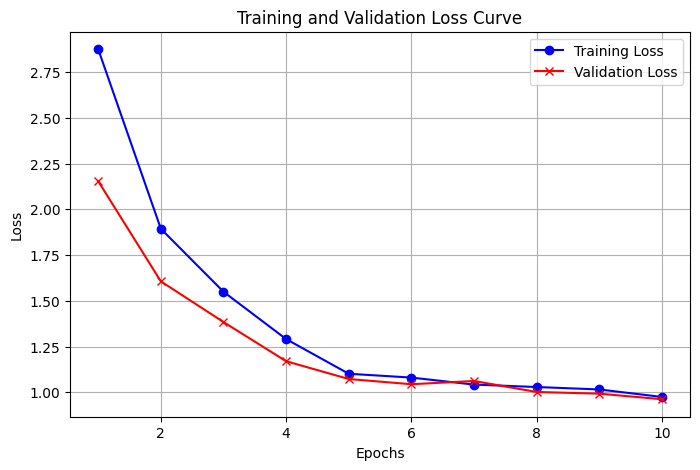

In [69]:
epochs_range = range(1, n_epochs + 1)


plt.figure(figsize=(8, 5))

plt.plot(epochs_range, train_losses, label='Training Loss', color='blue', marker='o')
plt.plot(epochs_range, validation_losses, label='Validation Loss', color='red', marker='x')

plt.title('Training and Validation Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()